# Conexión con LLMs

In [1]:
!pip install -q langchain langchain-google-genai google-generativeai


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install -q groq langchain-groq


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [3]:
# NO ESTA ACTIVA, es la primera versión pero gemini comenzó a colocar limites.
# from google.colab import userdata
# GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=1
)

In [6]:
respuesta = llm.invoke("en cinco líneas, ¿Qué es negocio de e-commerce?")

In [7]:
respuesta.content

'Un negocio de e-commerce es una empresa que vende productos o servicios en línea.\nUtiliza internet como plataforma para llegar a clientes y realizar transacciones.\nLos clientes pueden comprar y pagar en línea, y los productos se envían a su dirección.\nEste tipo de negocio puede ser B2B (empresa a empresa) o B2C (empresa a consumidor).\nEl e-commerce ha revolucionado la forma en que se realizan las compras y ha abierto oportunidades para empresas de todo tamaño.'

In [5]:
PROMPT_TRIAJE_ECOMMERCE = """
	Eres un especialista en triaje automatizado para el Service Desk de un E-commerce.
	Dado el mensaje del cliente, devuelve SÓLO un JSON con la siguiente estructura:\n
	{\n
	 "decision": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_TICKET_LOGISTICA" | "ESCALAR_URGENTE",\n
	 "urgencia": "BAJA" | "MEDIANA" | "ALTA" | "CRITICA",\n
	 "categoria": "DEVOLUCIONES" | "ENVIOS" | "PAGOS_Y_FACTURACION" | "PRODUCTO_Y_STOCK" | "SOPORTE_TECNICO",\n
	 "campos_faltantes": ["numero_pedido", "correo_registro", "motivo_especifico"]
	}\n

	Reglas para 'decision' y 'urgencia':

	- **AUTO_RESOLVER** (Urgencia: BAJA o MEDIANA):\n
	  * Consultas generales sobre políticas de envío, tablas de talles, horarios o métodos de pago.\n
	  * Ejemplos: "¿Cuánto tarda el envío a mi zona?", "¿Tienen cuotas sin interés?", "¿Cuál es su política de cambios?".\n

	- **PEDIR_INFO** (Urgencia: BAJA):\n
	  * El mensaje del cliente es impreciso, no especifica el problema o le faltan datos críticos para poder revisar el sistema (como el número de orden).\n
	  * Ejemplos: "Mi pedido no llegó", "Quiero hacer un cambio", "Tuve un problema con el pago".\n
	  * Nota: Rellenar la lista 'campos_faltantes' con los datos que se necesitan para procesar la ayuda.\n

	- **ABRIR_TICKET_LOGISTICA** (Urgencia: MEDIANA o ALTA):\n
	  * Solicitudes explícitas de cancelación de órdenes que aún no se han despachado, cambios de dirección de entrega urgentes o reclamos de productos faltantes en el paquete.\n
	  * Ejemplos: "Me equivoqué de dirección y compré hace una hora, cambien la dirección a Calle Falsa 123, a dos casas del kiosko chiringuito", "Me llegó el paquete, pero falta el pantalón".\n

	- **ESCALAR_URGENTE** (Urgencia: ALTA o CRITICA):\n
	  * Casos de sospecha de fraude, pasarelas de pago caídas que cobran doble, productos que llegaron rotos/dañados, o retrasos logísticos graves con más de 5 días de demora prometida.\n
	  * Ejemplos: "Me cobraron dos veces la misma compra", "El perfume llegó roto y derramado", "Mi pedido tenía fecha para el lunes pasado y sigue en viaje".\n

	Analiza el mensaje del cliente, define la 'categoria' correspondiente y decide la acción más adecuada.
"""


In [8]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

class TriajeOut(BaseModel):
  decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET_LOGISTICA", "ESCALAR_URGENTE"]
  urgencia: Literal["BAJA", "MEDIANA", "ALTA", "CRITICA"]
  categoria: Literal["DEVOLUCIONES", "ENVIOS", "PAGOS_Y_FACTURACION", "PRODUCTO_Y_STOCK", "SOPORTE_TECNICO"]
  campos_faltantes: List[str] = Field(default_factory=list)
  #campos_faltantes: ["numero_pedido", "correo_registro", "motivo_especifico"]

In [9]:
from langchain_core.messages import SystemMessage, HumanMessage

chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
  salida: TriajeOut = chain_de_triaje.invoke(
      [
          SystemMessage(content=PROMPT_TRIAJE_ECOMMERCE),
          HumanMessage(content=mensaje)
      ]
  )
  return salida.model_dump()

In [10]:
import time
from langchain_core.messages import SystemMessage, HumanMessage
from typing import Dict

# Re-initialize chain_de_triaje and triaje to ensure it uses the updated llm
chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
  salida: TriajeOut = chain_de_triaje.invoke(
      [
          SystemMessage(content=PROMPT_TRIAJE_ECOMMERCE),
          HumanMessage(content=mensaje)
      ]
  )
  return salida.model_dump()

mensajes_de_prueba = [
	"Hice una compra hace una semana para una dirección en zona urbana y el paquete todavía no me llegó, ¿dónde está?",
	"Me equivoqué al escribir la dirección de mi pedido, puse Calle Mexico 123 y era 1234, ¡ayuda antes de que lo envíen!",
	"Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto.",
	"El teléfono se me cayó al suelo por accidente, se rompió la pantalla y no prende. ¿Me lo cubre la garantía?",
	"Hola, mi producto de BimBam Buy dejó de funcionar de la nada y quiero usar la garantía de fábrica.",
	"Compré una campera hace 5 días, pero me arrepentí, está sin usar y quiero que me devuelvan el dinero.",
	"Me acaba de llegar el paquete, pero me mandaron unas zapatillas negras en vez de las rojas que compré.",
	"El banco me cobró la compra en la tarjeta, pero no me llegó ningún correo de confirmación ni número de orden.",
	"Intenté comprar, pero el sistema me rechaza la tarjeta todo el tiempo, ¿qué puedo hacer?",
	"Revisé mi cuenta del banco y me aparece que me cobraron dos veces exactamente el mismo monto por mi pedido.",
	"Ya me aprobaron la devolución del dinero, ¿cuánto tiempo tarda en verse reflejado el reembolso?",
	"Hola, envié mi postulación para el programa de afiliados hace unos días y quería saber si ya me aprobaron la cuenta.",
	"¿Qué pasa con mi comisión si un usuario compró con mi enlace de afiliado, pero luego devolvió el producto?",
	"Me llegó una alerta diciendo que mi cuenta de afiliado está suspendida por publicar precios incorrectos, exijo una revisión.",
	"¿Quién es Zinedine Zidane?"
]

for pregunta in mensajes_de_prueba:
  r = triaje(pregunta)
  print(f"{pregunta} -> {r}")
  time.sleep(1) # Reduced sleep to 1 second as Groq typically has higher rate limits, but keep it just in case

Hice una compra hace una semana para una dirección en zona urbana y el paquete todavía no me llegó, ¿dónde está? -> {'decision': 'PEDIR_INFO', 'urgencia': 'BAJA', 'categoria': 'ENVIOS', 'campos_faltantes': ['numero_pedido', 'correo_registro']}
Me equivoqué al escribir la dirección de mi pedido, puse Calle Mexico 123 y era 1234, ¡ayuda antes de que lo envíen! -> {'decision': 'ABRIR_TICKET_LOGISTICA', 'urgencia': 'ALTA', 'categoria': 'ENVIOS', 'campos_faltantes': ['numero_pedido']}
Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto. -> {'decision': 'ESCALAR_URGENTE', 'urgencia': 'ALTA', 'categoria': 'ENVIOS', 'campos_faltantes': ['numero_pedido', 'correo_registro']}
El teléfono se me cayó al suelo por accidente, se rompió la pantalla y no prende. ¿Me lo cubre la garantía? -> {'decision': 'PEDIR_INFO', 'urgencia': 'BAJA', 'categoria': 'SOPORTE_TECNICO', 'campos_faltantes': ['numero_pedido', 'fecha_compra', 'modelo_teléfono']}
Hol

# RAG

In [11]:
!pip install -q langchain_community faiss-cpu langchain-text-splitters pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [12]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for documento in Path("/content/BimBam Buy").glob("*.pdf"):
    try:
        loader = PyMuPDFLoader(str(documento))
        docs.extend(loader.load())
        print(f"Archivo cargado: {documento.name}")
    except Exception as e:
        print(f"Error cargando archivo: {documento.name}: {e}")

print(f"Total de documentos cargados: {len(docs)}")

/tmp/ipykernel_649/3606398991.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


Archivo cargado: Guía de Tiempos y Costos de Envío de BimBam Buy.pdf
Archivo cargado: Política de Reembolsos y Devoluciones de BimBam Buy.pdf
Archivo cargado: Programa de Afiliados de BimBam Buy.pdf
Archivo cargado: Manual de garantia de productos de BimBam Buy.pdf
Archivo cargado: Preguntas frecuentes sobre metodos de pagos BimBam Buy.pdf
Total de documentos cargados: 57


In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)

In [14]:
for chunk in chunks:
  print(chunk)
  print("------------------")

page_content='Guía de Tiempos y Costos de Envío de BimBam Buy
Índice
1. Propósito
2. Alcance
3. Principios de envío
4. Tipos de envío
5. Tiempos estimados
6. Costos de envío
7. Envío gratis
8. Costos por tipo de incidencia
9. Cobertura geográfica
10. Restricciones operativas
11. Seguimiento de pedidos' metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '2026-06-16T15:02:16-03:00', 'source': '/content/BimBam Buy/Guía de Tiempos y Costos de Envío de BimBam Buy.pdf', 'file_path': '/content/BimBam Buy/Guía de Tiempos y Costos de Envío de BimBam Buy.pdf', 'total_pages': 12, 'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-06-16T15:02:16-03:00', 'trapped': '', 'modDate': "D:20260616150216-03'00'", 'creationDate': "D:20260616150216-03'00'", 'page': 0}
------------------
page_content='11. Seguimiento de pedidos
12. Incidencias logísticas
13. Coordinación con devoluciones
14. Coordinación con garantía
15. Factores de costo por categor

In [ ]:
len(chunks)

300

In [15]:
!pip install -q langchain-huggingface sentence-transformers

In [16]:
from langchain_huggingface import HuggingFaceEmbeddings

In [17]:
modelo_embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# from langchain_google_genai import GoogleGenerativeAIEmbeddings
# modelo_embeddings = GoogleGenerativeAIEmbeddings(
#     model="models/gemini-embedding-001",
#     google_api_key=GEMINI_API_KEY
# )
# NO ESTÁ ACTIVA

In [18]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, modelo_embeddings)

retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.3, "k": 4}
)

In [19]:
!pip install -q langchain langchain-core

In [20]:
!pip install -q langchain-classic

In [22]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate
prompt_rag = ChatPromptTemplate(
    [
        ("system",
         """
         Eres el especialista principal de Soporte Técnico y Experiencia del Cliente para nuestro E-commerce.
         Tu objetivo es brindar respuestas claras, amables, empáticas y altamente resolutivas, priorizando siempre la satisfacción del cliente.

         REGLAS DE OPERACIÓN SEVERAS:
         1. Confía ÚNICAMENTE en la información proporcionada en el 'Contexto' para responder la pregunta.
         2. Si el 'Contexto' no contiene la información necesaria para responder de forma precisa, di exactamente: "Lo siento, en este momento no tengo esa información disponible. Por favor, aguarda un momento y te comunicaré con un agente humano para ayudarte."
         3. No inventes políticas, precios, plazos de envío ni condiciones que no estén explícitamente escritos en el contexto.
         4. Mantén un tono profesional pero cercano (trata al cliente de "tú" o "usted" según la identidad de tu marca, idealmente "tú" de forma respetuosa).
         """),
        ("human", "Contexto de soporte de la empresa:\n{context}\n\nConsulta o reclamo del cliente:\n{input}")
    ]
)

document_chain = create_stuff_documents_chain(llm, prompt_rag)

In [23]:
def busqueda_de_respuestas_RAG(pregunta) -> Dict:
  documentos_relacionados = retriever.invoke(pregunta)

  if not documentos_relacionados:
    return {
        "respuesta": "No lo sé.",
        "citaciones": [],
        "documentos_encontrados": False
        }

  answer = document_chain.invoke({
      "input": pregunta,
      "context": documentos_relacionados
  })

  if answer.rstrip(".!?") == 'No lo sé':
    return {
        "respuesta": "No lo sé.",
        "citaciones": [],
        "documentos_encontrados": False
        }

  return {
        "respuesta": answer,
        "citaciones": documentos_relacionados,
        "documentos_encontrados": True
        }


In [24]:
r = busqueda_de_respuestas_RAG("Hola, mi producto de BimBam Buy dejó de funcionar de la nada y quiero usar la garantía de fábrica ¿Que debo hacer?")
print(r)

{'respuesta': 'Hola, gracias por contactarnos. Lamentamos saber que tu producto dejó de funcionar. Para poder ayudarte con la garantía de fábrica, necesitamos revisar el caso con detalle.\n\nPor favor, puedes decirme un poco más sobre el problema que estás experimentando con tu producto? ¿Cuándo comenzó a tener problemas y qué síntomas has notado exactamente? También es importante saber si el producto sufrió algún daño durante el transporte o si el problema parece surgir de la fábrica.\n\nAdemás, te pedimos que mantengas el producto en condiciones razonables hasta que podamos inspeccionarlo. Es importante evitar cualquier reparación no autorizada, ya que esto podría afectar la validez de la garantía.\n\nUna vez que tengamos más información, podremos proceder según lo establecido en nuestro Manual de Garantía de Productos y la Política de Reembolsos y Devoluciones de BimBam Buy. Nuestro equipo revisará cada caso con criterio uniforme para asegurarnos de que recibas la atención y solució

In [25]:
len(r["citaciones"])

4

In [26]:
mensajes_de_prueba = [
	"Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto. ¿que hago?",
	"El teléfono se me cayó al suelo por accidente, se rompió la pantalla y no prende. ¿Me lo cubre la garantía?",
	"Hice una compra hace una semana para una dirección en zona urbana y el paquete todavía no me llegó, ¿dónde está?",
	"Me equivoqué al escribir la dirección de mi pedido, puse Calle México 123 y era 1234, ¡ayuda antes de que lo envíen!",
	"Hola, mi producto de BimBam Buy dejó de funcionar de la nada y quiero usar la garantía de fábrica.",
	"Compré una campera hace 5 días, pero me arrepentí, está sin usar y quiero que me devuelvan el dinero.",
	"me llego el paquete, pero me mandaron unas zapatillas negras en vez de las rojas que compré.",
	"El banco me cobró la compra en la tarjeta, pero no me llegó ningún correo de confirmación ni número de orden.",
	"Ya me aprobaron la devolución del dinero, ¿cuánto tiempo tarda en verse reflejado el reembolso?",
	"Hola, envié mi postulación para el programa de afiliados hace unos días y quería saber si ya me aprobaron la cuenta.",
	"¿Qué pasa con mi comisión si un usuario compró con mi enlace de afiliado, pero luego devolvió el producto?",
	"¿Quién es Zinedin Zidane?"
]

In [27]:
for pregunta in mensajes_de_prueba:
  respuesta_RAG = busqueda_de_respuestas_RAG(pregunta)
  print(f"PREGUNTA: {pregunta}")
  print(f"RESPUESTA: {respuesta_RAG['respuesta']}")
  if respuesta_RAG['documentos_encontrados']:
    for i, citacion in enumerate(respuesta_RAG['citaciones']):
      print(f"    - CITACIÓN {i + 1}:")
      print(f"      Camino del documento: {citacion.metadata['file_path']}")
      print(f"      Contenido: {citacion.page_content.replace('\n', '')}")
  print("----------------------------------------------------------------")

PREGUNTA: Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto. ¿que hago?
RESPUESTA: Lo siento mucho que hayas recibido tu paquete en mal estado y que el producto esté roto. ¡Eso es muy frustrante!

En este caso, te recomiendo que iniciemos un proceso de devolución o reembolso. Como el producto está roto y el paquete llegó dañado, es probable que se trate de un problema con el envío.

Te sugiero que te comuniques conmigo para que podamos evaluar la situación y encontrar la mejor solución para ti. Podemos considerar una devolución del producto y un reembolso total o parcial, según sea necesario.

Antes de proceder, necesitaría que me proporciones algunos detalles adicionales, como el número de pedido y una descripción detallada del daño al producto y al paquete. Esto me ayudará a entender mejor la situación y a encontrar la solución más adecuada para ti.

¿Estás de acuerdo en proporcionarme más información para que podamos avanz

PREGUNTA: ¿Qué pasa con mi comisión si un usuario compró con mi enlace de afiliado, pero luego devolvió el producto?
RESPUESTA: Lo siento, en este momento no tengo esa información disponible. Por favor, aguarda un momento y te comunicaré con un agente humano para ayudarte.
    - CITACIÓN 1:
      Camino del documento: /content/BimBam Buy/Política de Reembolsos y Devoluciones de BimBam Buy.pdf
      Contenido: •  Productos consumibles ya abiertos, salvo defecto comprobado•  Artículos alterados, lavados, modificados o incompletos por causas ajenas a la operación•  Solicitudes presentadas fuera de plazo•  Insatisfacción subjetiva sin relación con el producto entregado y sin cumplimiento de
    - CITACIÓN 2:
      Camino del documento: /content/BimBam Buy/Política de Reembolsos y Devoluciones de BimBam Buy.pdf
      Contenido: corridos y el producto está sin uso. Se acepta devolución por retracto.Ejemplo 3
    - CITACIÓN 3:
      Camino del documento: /content/BimBam Buy/Política de Reembo

# Agente con LangGraph

In [28]:
!pip install -q langgraph

In [29]:
from typing import TypedDict, Optional

class AgentState(TypedDict, total = False):
  pregunta: str
  triaje: dict
  respuesta: Optional[str]
  citaciones: Optional[list]
  rag_exito: bool
  accion_final: str

In [30]:
def nodo_triaje(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'triaje'...")
  return {"triaje": triaje(state["pregunta"])}

In [31]:
def nodo_auto_resolver(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'auto_resolver'...")
  respuesta_RAG = busqueda_de_respuestas_RAG(state["pregunta"])

  update: AgentState = {
      "respuesta": respuesta_RAG["respuesta"],
      "citaciones": respuesta_RAG["citaciones"],
      "rag_exito": respuesta_RAG["documentos_encontrados"]
  }

  if respuesta_RAG["documentos_encontrados"]:
    update["accion_final"] = "AUTO_RESOLVER"

  return update

In [32]:
def nodo_pedir_info(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'pedir_info'...")
  return {
      "respuesta": "Necesito más informaciones sobre tu pedido.",
      "citaciones": [],
      "accion_final": "PEDIR_INFO"
  }

In [33]:
def nodo_abrir_ticket(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'abrir_ticket'...")

  tri = state["triaje"]

  return {
      "respuesta": f"Abrir ticket con urgencia {tri['urgencia']}. Pedido: {state['pregunta']}.",
      "citaciones": [],
      "accion_final": "ABRIR_TICKET"
  }

In [34]:
def arista_decision_triaje(state: AgentState) -> str:
  print("Decidiendo el flujo después del nodo 'triaje'...")
  tri = state["triaje"]

  if tri["decision"] == "AUTO_RESOLVER":
    return "rag"
  elif tri["decision"] == "PEDIR_INFO":
    return "info"
  else:
    return "ticket"

In [35]:
def arista_decision_rag(state: AgentState) -> str:
  print("Decidiendo el flujo después del nodo 'auto_resolver'...")

  if state["rag_exito"]:
    print("RAG con éxito, finalizando el flujo.")
    return "ok"

  KEYWORDS_ABRIR_TICKET = ["aprobación", "aprobar", "excepción", "liberación", "autorización",
                         "autorizar", "abrir ticket", "acceso especial"]

  if any(keyword in state["pregunta"].lower() for keyword in KEYWORDS_ABRIR_TICKET):
    print("RAG ha fallado, pero hay palabras relacionadas con abrir ticket.")
    return "ticket"

  print("RAG ha fallado, pediré más informaciones al usuario.")
  return "info"

In [36]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "ticket": "abrir_ticket"
})

workflow.add_conditional_edges("auto_resolver", arista_decision_rag, {
    "info": "pedir_info",
    "ticket": "abrir_ticket",
    "ok": END
})

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_ticket", END)

grafo = workflow.compile()

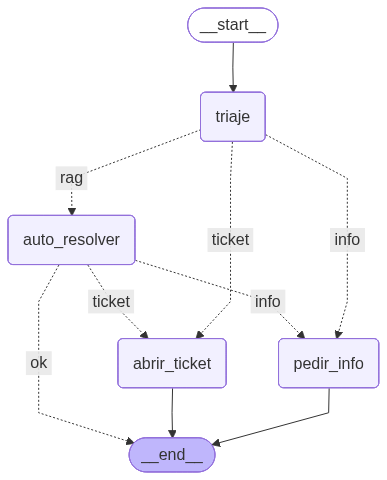

In [37]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [40]:
PREGUNTA = "¿tienen alguna política de rembolso?"

respuesta = grafo.invoke({"pregunta": PREGUNTA})
print("")
print(f"PREGUNTA: {PREGUNTA}")
print(f"DECISIÓN DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta['triaje']['urgencia']} | ACCIÓN FINAL: {respuesta['accion_final']}")
print(f"RESPUESTA: {respuesta['respuesta']}")
if respuesta['citaciones']:
  for i, citacion in enumerate(respuesta['citaciones']):
    print(f"    - CITACIÓN {i + 1}:")
    print(f"      Camino del documento: {citacion.metadata['file_path']}")
    print(f"      Contenido: {citacion.page_content.replace('\n', '')}")

Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con éxito, finalizando el flujo.

PREGUNTA: ¿tienen alguna política de rembolso?
DECISIÓN DE TRIAJE: AUTO_RESOLVER | URGENCIA: BAJA | ACCIÓN FINAL: AUTO_RESOLVER
RESPUESTA: Sí, tenemos una política de rembolso en BimBam Buy. De acuerdo con nuestra política, podemos gestionar reembolsos en caso de devolución o problemas con la compra. La logística para el reembolso se gestiona conforme a nuestra Política de Reembolsos y Devoluciones. Sin embargo, no tengo información detallada sobre los plazos o condiciones específicas para cada tipo de reembolso en este momento. ¿Hay algo en particular que te gustaría saber sobre nuestra política de rembolso o tienes un problema específico con tu compra que te gustaría resolver? Estoy aquí para ayudarte.
    - CITACIÓN 1:
      Camino del documento: /content/BimBam Buy/Política de Re

In [41]:
mensajes_de_prueba = [
	"El banco me cobró la compra en la tarjeta, pero no me llegó ningún correo de confirmación ni número de orden. Preciso respuest",
	"Intenté comprar, pero el sistema me rechaza la tarjeta todo el tiempo, ¿qué puedo hacer?",
	"Ya me aprobaron la devolución del dinero, ¿cuánto tiempo tarda en verse reflejado el reembolso?",
	"Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto. necesito devolverlo",
	"Hola, envié mi postulación para el programa de afiliados hace unos días y quería saber si ya me aprobaron la cuenta.",
	"¿Qué pasa con mi comisión si un usuario compró con mi enlace de afiliado, pero luego devolvió el producto?",
	"¿Quién fue Ronaldinho Gaucho?"
]

In [42]:
for prueba in mensajes_de_prueba:
  respuesta = grafo.invoke({"pregunta": prueba})
  print("")
  print(f"PREGUNTA: {prueba}")
  print(f"DECISIÓN DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta['triaje']['urgencia']} | ACCIÓN FINAL: {respuesta['accion_final']}")
  print(f"RESPUESTA: {respuesta['respuesta']}")
  if respuesta['citaciones']:
    for i, citacion in enumerate(respuesta['citaciones']):
      print(f"    - CITACIÓN {i + 1}:")
      print(f"      Camino del documento: {citacion.metadata['file_path']}")
      print(f"      Contenido: {citacion.page_content.replace('\n', '')}")
  print("-----------------------------------------------")

Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'pedir_info'...

PREGUNTA: El banco me cobró la compra en la tarjeta, pero no me llegó ningún correo de confirmación ni número de orden. Preciso respuest
DECISIÓN DE TRIAJE: PEDIR_INFO | URGENCIA: BAJA | ACCIÓN FINAL: PEDIR_INFO
RESPUESTA: Necesito más informaciones sobre tu pedido.
-----------------------------------------------
Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'pedir_info'...

PREGUNTA: Intenté comprar, pero el sistema me rechaza la tarjeta todo el tiempo, ¿qué puedo hacer?
DECISIÓN DE TRIAJE: PEDIR_INFO | URGENCIA: BAJA | ACCIÓN FINAL: PEDIR_INFO
RESPUESTA: Necesito más informaciones sobre tu pedido.
-----------------------------------------------
Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con éxito, final